<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
">
  Regresion lineal para analizar la relacion entre variables socio demograficas, recursos de salud y prevalencia de diabetes en condados de Estados Unidos.

</h2>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Carga de librerias y del conjunto de datos
</h2>

In [5]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
📥 Lectura del dataset
</h2>

In [6]:
df = pd.read_csv("../data/raw/demographic_health_data.csv")
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,60-69 y/o % of total pop,70-79,70-79 y/o % of total pop,80+,80+ y/o % of total pop,White-alone pop,% White-alone,Black-alone pop,% Black-alone,Native American/American Indian-alone pop,% NA/AI-alone,Asian-alone pop,% Asian-alone,Hawaiian/Pacific Islander-alone pop,% Hawaiian/PI-alone,Two or more races pop,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Less than a high school diploma 2014-18,High school diploma only 2014-18,Some college or associate's degree 2014-18,Bachelor's degree or higher 2014-18,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,MEDHHINC_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,13.636445,7738,13.917016,5826,10.478229,4050,7.284042,2014,3.622237,42660,76.725239,10915,19.630942,267,0.480207,681,1.224798,62,0.111509,1016,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,4204,12119,10552,10291,11.3,32.6,28.4,27.7,7587,13.8,19.3,19.5,59338,53628,65048,25957,25015,942,3.6,59338,119.0,217.1,196.7,77.2,71.2,7.6,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,10523,19.1,Autauga,Alabama,1,1,42438,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,12.539102,29986,13.753658,29932,13.728890,20936,9.602701,9368,4.296814,190301,87.285228,19492,8.940382,1684,0.772399,2508,1.150343,146,0.066966,3891,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,14310,40579,46025,46075,9.7,27.6,31.3,31.3,21069,9.8,13.9,13.1,57588,54437,60739,93849,90456,3393,3.6,57588,115.5,217.1,196.7,77.2,71.2,7.6,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,53519,26.3,Baldwin,Alabama,1,3,170912,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,12.354809,3278,13.174712,3076,12.3

In [7]:
print(df.shape)
print(df.columns.tolist())

(3140, 108)
['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct', '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop', '30-39', '30-39 y/o % of total pop', '40-49', '40-49 y/o % of total pop', '50-59', '50-59 y/o % of total pop', '60-69', '60-69 y/o % of total pop', '70-79', '70-79 y/o % of total pop', '80+', '80+ y/o % of total pop', 'White-alone pop', '% White-alone', 'Black-alone pop', '% Black-alone', 'Native American/American Indian-alone pop', '% NA/AI-alone', 'Asian-alone pop', '% Asian-alone', 'Hawaiian/Pacific Islander-alone pop', '% Hawaiian/PI-alone', 'Two or more races pop', '% Two or more races', 'POP_ESTIMATE_2018', 'N_POP_CHG_2018', 'GQ_ESTIMATES_2018', 'R_birth_2018', 'R_death_2018', 'R_NATURAL_INC_2018', 'R_INTERNATIONAL_MIG_2018', 'R_DOMESTIC_MIG_2018', 'R_NET_MIG_2018', 'Less than a high school diploma 2014-18', 'High school diploma only 2014-18', "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18", 'Percent of adu

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
🔍 Inspeccion inicial del dataset
</h2>

In [8]:
print("Dimensiones del dataset:", df.shape)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nFilas duplicadas:", df.duplicated().sum())

Dimensiones del dataset: (3140, 108)

Valores nulos por columna:
fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64

Filas duplicadas: 0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Revision de la variable objetivo
</h2>

In [10]:
target = "diabetes_prevalence"

print(df[target].describe())

count    3140.000000
mean       13.073503
std         2.724351
min         6.100000
25%        11.200000
50%        12.800000
75%        14.800000
max        25.600000
Name: diabetes_prevalence, dtype: float64


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
">
📈 Visualizacion de la distribucion de la variable objetivo
</h2>

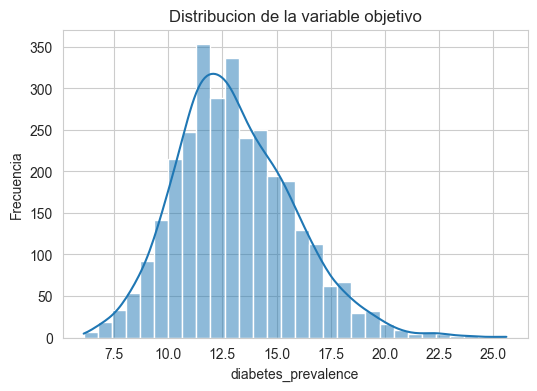

In [11]:
plt.figure(figsize=(6, 4))
sns.histplot(df[target], bins=30, kde=True)
plt.title("Distribucion de la variable objetivo")
plt.xlabel("diabetes_prevalence")
plt.ylabel("Frecuencia")
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">La variable <span style="color: #ef4444; font-weight: 700;">diabetes_prevalence</span> presenta una distribucion continua y relativamente concentrada, con la mayor parte de los condados agrupados en valores intermedios. Lo que quiero decir es que la mayoria de los territorios no estan en extremos muy bajos ni muy altos, lo que facilita usar un modelo de regresion para estimar el nivel de prevalencia de diabetes.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Tratamiento de filas duplicadas y columnas con posible data leakage
</h2>

In [12]:
print("Filas antes de eliminar duplicados:", df.shape[0])

df = df.drop_duplicates()

possible_leakage_columns = [
    "diabetes_Lower 95% CI",
    "diabetes_Upper 95% CI",
    "diabetes_number"
]

identifier_columns = [
    "fips",
    "STATE_FIPS",
    "CNTY_FIPS",
    "COUNTY_NAME"
]

columns_to_drop = [col for col in possible_leakage_columns + identifier_columns if col in df.columns]
df = df.drop(columns=columns_to_drop)

print("Filas despues de eliminar duplicados:", df.shape[0])
print("Duplicados restantes:", df.duplicated().sum())

print("\nColumnas eliminadas:")
print(columns_to_drop)

Filas antes de eliminar duplicados: 3140
Filas despues de eliminar duplicados: 3140
Duplicados restantes: 0

Columnas eliminadas:
['diabetes_Lower 95% CI', 'diabetes_Upper 95% CI', 'diabetes_number', 'fips', 'STATE_FIPS', 'CNTY_FIPS', 'COUNTY_NAME']


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se eliminaron estas columnas porque no ayudaban a construir un modelo mas justo y claro. Algunas eran codigos o nombres que solo servian para identificar el condado, pero no aportaban informacion real sobre las condiciones de salud o del entorno. Otras estaban demasiado relacionadas con la variable objetivo, por lo que dejarlas podia hacer que el modelo pareciera mejor de lo que en realidad es. En resumen, se quitaron para evitar ruido, evitar ventajas artificiales y trabajar solo con variables que realmente aportaran valor al analisis.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Tratamiento de valores nulos en la variable objetivo
</h2>

In [13]:
print("Valores nulos en diabetes_prevalence antes de limpiar:", df[target].isna().sum())

df = df.dropna(subset=[target])

print("Valores nulos en diabetes_prevalence despues de limpiar:", df[target].isna().sum())
print("Dimensiones del dataset despues de limpiar el target:", df.shape)

Valores nulos en diabetes_prevalence antes de limpiar: 0
Valores nulos en diabetes_prevalence despues de limpiar: 0
Dimensiones del dataset despues de limpiar el target: (3140, 101)


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Clasificacion de variables numericas y categoricas
</h2>

In [21]:
numeric_features = df.select_dtypes(include=["number"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()

if target in numeric_features:
    numeric_features.remove(target)
    
n_cols = 3
n_rows = (len(numeric_features) + n_cols - 1) // n_cols

numeric_rows = []
for i in range(n_rows):
    fila = []
    for j in range(n_cols):
        idx = i + j * n_rows
        if idx < len(numeric_features):
            fila.append(numeric_features[idx])
        else:
            fila.append("")
    numeric_rows.append(fila)

numeric_table = pd.DataFrame(
    numeric_rows,
    columns=["","",""])

numeric_table.style.hide(axis="index")

,,
TOT_POP,GQ_ESTIMATES_2018,Active Patient Care General Surgeons per 100000 Population 2018 (AAMC)
0-9,R_birth_2018,Total nurse practitioners (2019)
0-9 y/o % of total pop,R_death_2018,Total physician assistants (2019)
19-Oct,R_NATURAL_INC_2018,Total Hospitals (2019)
10-19 y/o % of total pop,R_INTERNATIONAL_MIG_2018,Internal Medicine Primary Care (2019)
20-29,R_DOMESTIC_MIG_2018,Family Medicine/General Practice Primary Care (2019)
20-29 y/o % of total pop,R_NET_MIG_2018,Total Specialist Physicians (2019)
30-39,Less than a high school diploma 2014-18,ICU Beds_x
30-39 y/o % of total pop,High school diploma only 2014-18,Total Population
40-49,Some college or associate's degree 2014-18,Population Aged 60+


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">De este modo tengo un mayor control visual de las variables numericas.</p>
</div>

In [42]:
categorical_features = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
print("\nVariables categoricas:")
print(categorical_features)


Variables categoricas:
['STATE_NAME']


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Resumen estadistico de variables numericas
</h2>

In [12]:
df[numeric_features + [target]].describe().T

,count,mean,std,min,25%,50%,75%,max
TOT_POP,3140.0,104189.412420,333583.395432,88.0,10963.250000,25800.500000,67913.000000,1.010552e+07
0-9,3140.0,12740.302866,41807.301846,0.0,1280.500000,3057.000000,8097.000000,1.208253e+06
0-9 y/o % of total pop,3140.0,11.871051,2.124081,0.0,10.594639,11.802727,12.951840,2.546068e+01
19-Oct,3140.0,13367.976752,42284.392134,0.0,1374.500000,3274.000000,8822.250000,1.239139e+06
10-19 y/o % of total pop,3140.0,12.694609,1.815044,0.0,11.674504,12.687422,13.659282,2.330437e+01
...,...,...,...,...,...,...,...,...
CKD_Lower 95% CI,3140.0,3.207516,0.527740,1.7,2.900000,3.200000,3.500000,5.800000e+00
CKD_Upper 95% CI,3140.0,3.710478,0.613069,1.9,3.300000,3.700000,4.100000,6.600000e+00
CKD_number,3140.0,2466.234076,7730.422067,3.0,314.750000,718.000000,1776.250000,2.377660e+05
Urban_rural_code,3140.0,4.635350,1.510447,1.0,3.000000,5.000000,6.000000,6.000000e+00


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
📈 Distribucion de variables numericas
</h2>

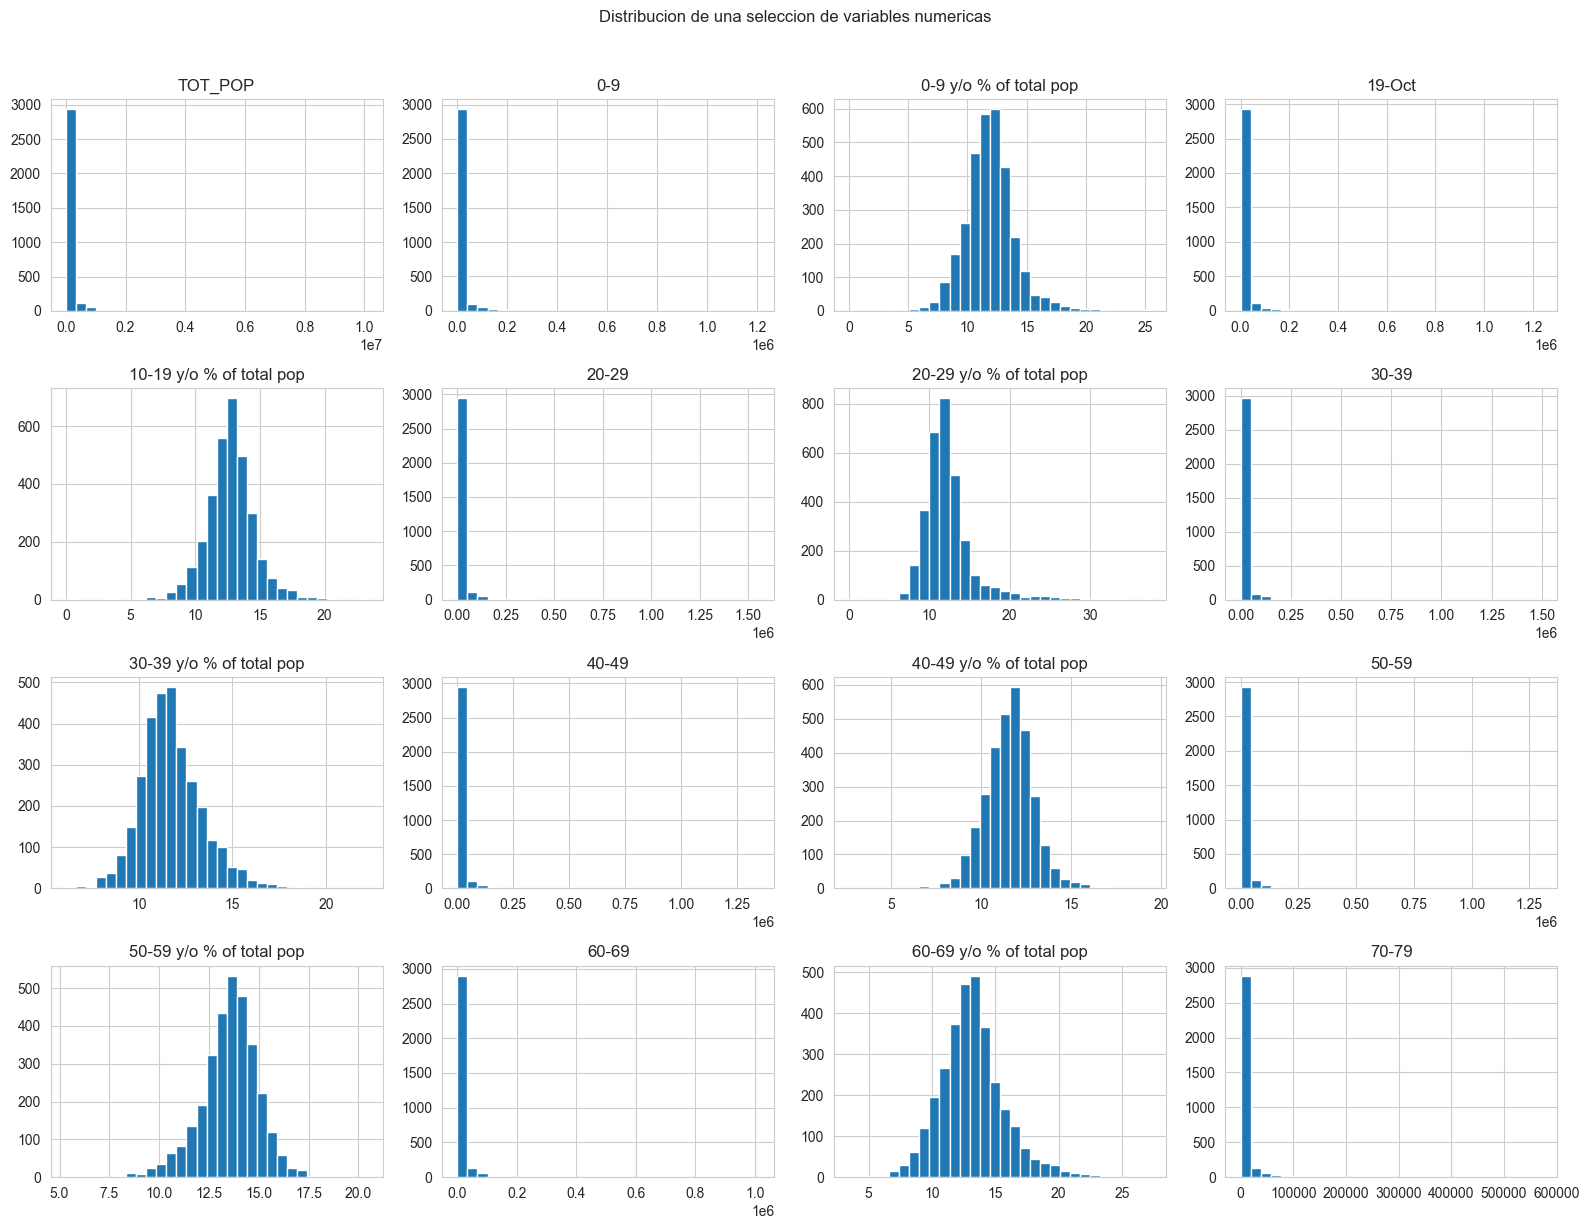

In [13]:
df[numeric_features[:16]].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distribucion de una seleccion de variables numericas", y=1.02)
plt.tight_layout()
plt.show()

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
📈 Deteccion visual de outliers en variables numericas
</h2>

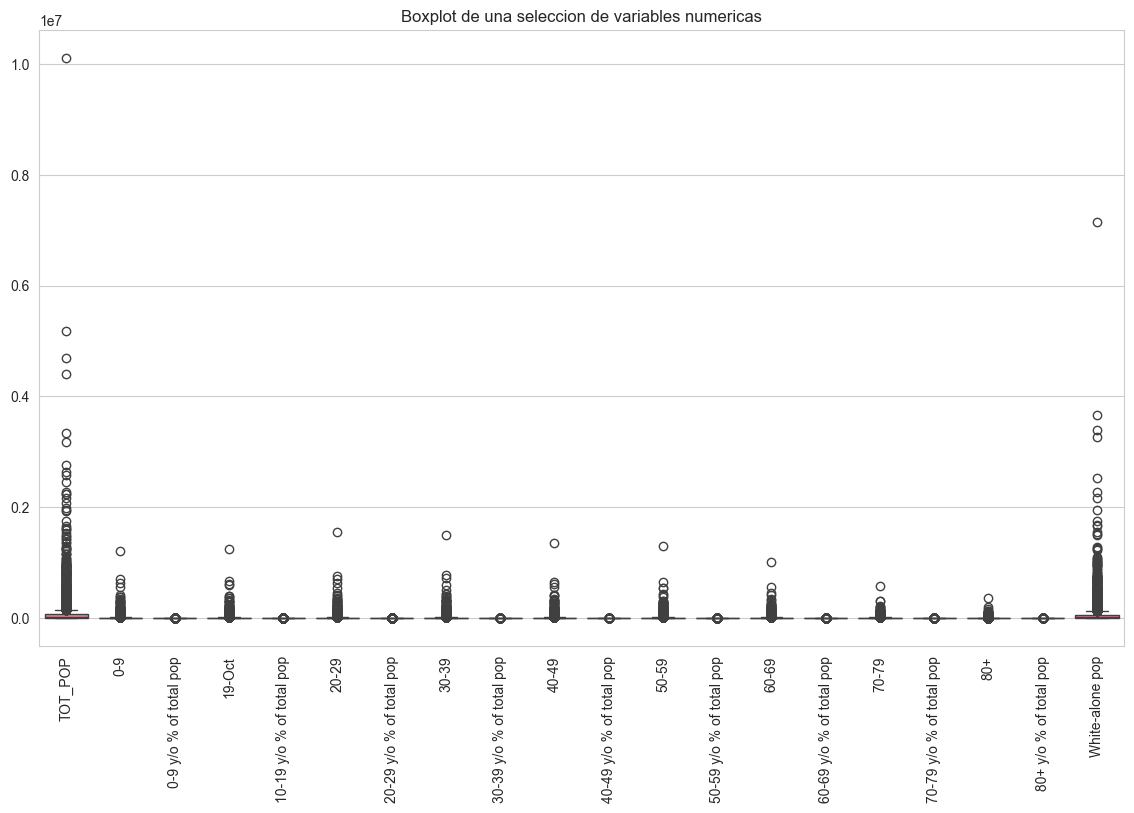

In [14]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df[numeric_features[:20]])
plt.xticks(rotation=90)
plt.title("Boxplot de una seleccion de variables numericas")
plt.show()

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Conclusiones iniciales de las variables numericas
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">A partir de los histogramas y boxplots observo que varias variables numericas presentan distribuciones sesgadas y valores alejados del centro. Dicho de forma simple, no todos los condados se parecen entre si. Algunos tienen tamaños de poblacion, niveles de pobreza o recursos sanitarios muy distintos. Esto es importante porque le da sentido al problema de prediccion, pero tambien indica que el preprocesamiento debe manejar bien las escalas y la variabilidad.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Analisis de variables categoricas
</h2>

In [15]:
categorical_features = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()

for col in categorical_features:
    print(f"\nFrecuencias de {col}:")
    print(df[col].value_counts().head(15))


Frecuencias de STATE_NAME:
STATE_NAME
Texas             254
Georgia           159
Virginia          133
Kentucky          120
Missouri          115
Kansas            105
Illinois          102
North Carolina    100
Iowa               99
Tennessee          95
Nebraska           93
Indiana            92
Ohio               88
Minnesota          87
Michigan           83
Name: count, dtype: int64


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
📈 Distribucion de la variable categorica principal
</h2>

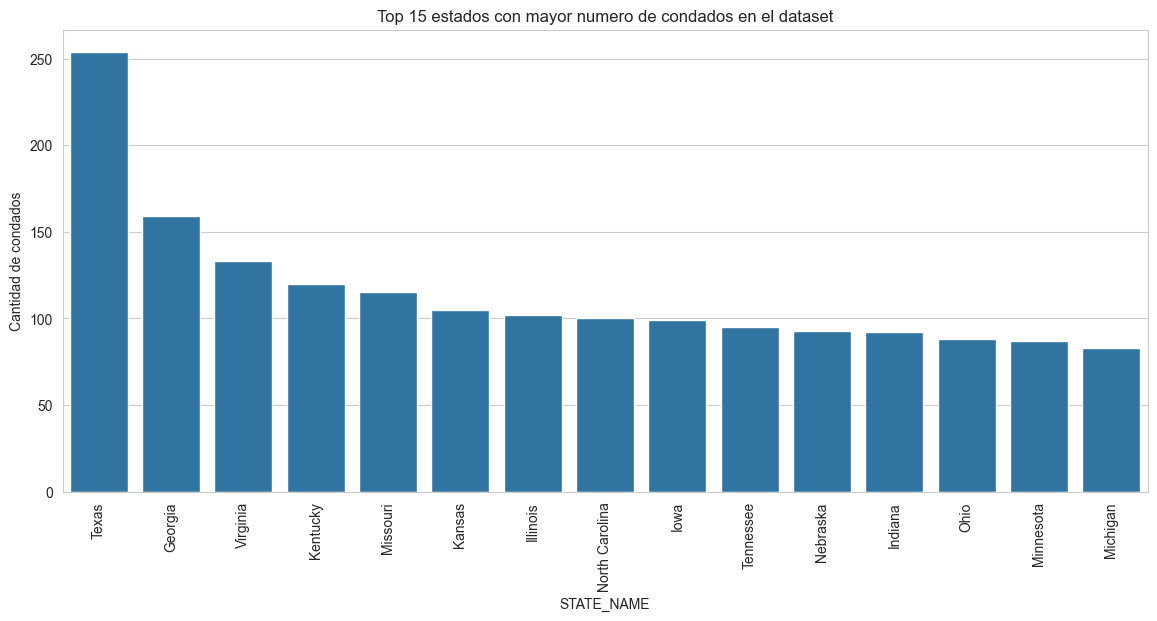

In [16]:
plt.figure(figsize=(14, 6))
state_counts = df["STATE_NAME"].value_counts().head(15)
sns.barplot(x=state_counts.index, y=state_counts.values)
plt.xticks(rotation=90)
plt.title("Top 15 estados con mayor numero de condados en el dataset")
plt.xlabel("STATE_NAME")
plt.ylabel("Cantidad de condados")
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">La variable <span style="color: #ef4444; font-weight: 700;">STATE_NAME</span> aporta una capa geografica interesante porque permite capturar diferencias regionales entre condados. En lenguaje simple, esto quiere decir que el modelo no solo vera numeros sueltos, sino tambien el contexto territorial en el que se encuentra cada condado.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
📈 Correlacion entre variables numericas
</h2>

<div style="
  font-size: 20px;
  line-height: 1.7;
  color: #1f2937;
  background-color: #f8fafc;
  border-left: 6px solid #38bdf8;
  padding: 16px 18px;
  border-radius: 10px;
">
En lugar de mostrar una matriz gigante dificil de leer, selecciono las variables numericas con mayor relacion lineal con la variable objetivo. Asi la lectura resulta mas clara.
</div>

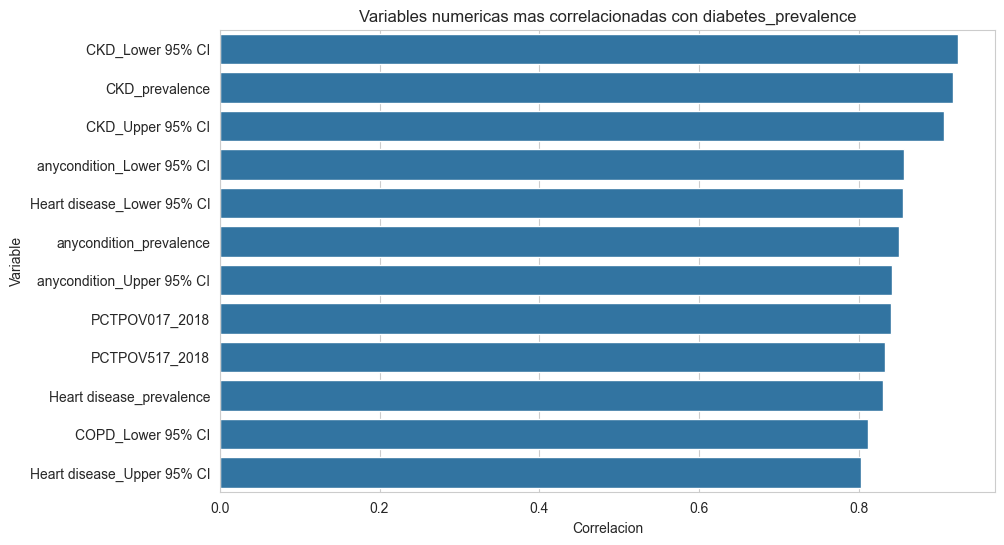

In [17]:
correlations = df[numeric_features + [target]].corr(numeric_only=True)[target].drop(target)
top_corr = correlations.sort_values(key=lambda s: s.abs(), ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Variables numericas mas correlacionadas con diabetes_prevalence")
plt.xlabel("Correlacion")
plt.ylabel("Variable")
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Para saber cuáles variables estaban más relacionadas con la variable objetivo, se calculó la relación de cada variable numérica con <span style="color: #ef4444; font-weight: 700;">diabetes_prevalence</span>. Después se ordenaron esos resultados de mayor a menor y se seleccionaron las que mostraban la relación más fuerte. Estas variables son las que mas parecen estar conectadas con <span style="color: #ef4444; font-weight: 700;">diabetes_prevalence</span> dentro del conjunto de datos. Esto no quiere decir que una sea la causa directa de la otra, pero si nos da una señal clara de que cambian de forma parecida. Dicho de una manera mas simple, cuando ciertas condiciones de salud o del entorno suben o bajan, la diabetes tambien suele moverse. Esta parte es importante porque ayuda a identificar que factores parecen tener mas peso dentro del problema que estamos estudiando.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
⚙️ Preparacion de los datos para el modelado
</h2>

In [18]:
X = df.drop(columns=[target])
y = df[target]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (3140, 100)
Dimensiones de y: (3140,)


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Division en entrenamiento y prueba
</h2>

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2512, 100)
X_test: (628, 100)
y_train: (2512,)
y_test: (628,)


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
">
Identificacion de variables numericas y categoricas para el pipeline
</h2>

In [20]:
categorical_features = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()

print("Variables numericas del pipeline:", len(numeric_features))
print("Variables categoricas del pipeline:", len(categorical_features))

Variables numericas del pipeline: 99
Variables categoricas del pipeline: 1


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Preprocesamiento de variables
</h2>

<div style="
  font-size: 20px;
  line-height: 1.7;
  color: #1f2937;
  background-color: #f8fafc;
  border-left: 6px solid #38bdf8;
  padding: 16px 18px;
  border-radius: 10px;
">
Antes de entrenar el modelo, hay que preparar bien los datos. No todas las columnas son iguales, unas tienen numeros y otras tienen palabras o categorias. Por eso no se pueden tratar de la misma manera. En las columnas numericas se rellenan los valores faltantes y se ordenan para que queden en una escala parecida. En las columnas categoricas tambien se rellenan los valores faltantes, pero ademas se transforman a un formato que el modelo pueda entender. Todo esto se hace dentro de un mismo proceso para que el trabajo sea mas limpio, mas ordenado y mas seguro, de hecho esta es la manera mas eficiente que he visto para realizarlo.
</div>

In [21]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocesador creado correctamente.")

Preprocesador creado correctamente.


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Modelo baseline de regresion lineal
</h2>

In [ ]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())])

baseline_model.fit(X_train, y_train)

print("Modelo baseline entrenado correctamente.")

Modelo baseline entrenado correctamente.


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
">
Evaluacion del modelo baseline
</h2>

In [ ]:
y_train_pred = baseline_model.predict(X_train)
y_test_pred = baseline_model.predict(X_test)

baseline_metrics = pd.DataFrame({
    "dataset": ["train", "test"],
    "r2": [
        r2_score(y_train, y_train_pred),
        r2_score(y_test, y_test_pred)
    ],
    "mae": [
        mean_absolute_error(y_train, y_train_pred),
        mean_absolute_error(y_test, y_test_pred)
    ],
    "rmse": [
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        np.sqrt(mean_squared_error(y_test, y_test_pred))]})

baseline_metrics

,dataset,r2,mae,rmse
0,train,0.989327,0.210708,0.278336
1,test,0.988947,0.220756,0.298157


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
📈 Comparacion visual entre valores reales y predichos del modelo baseline
</h2>

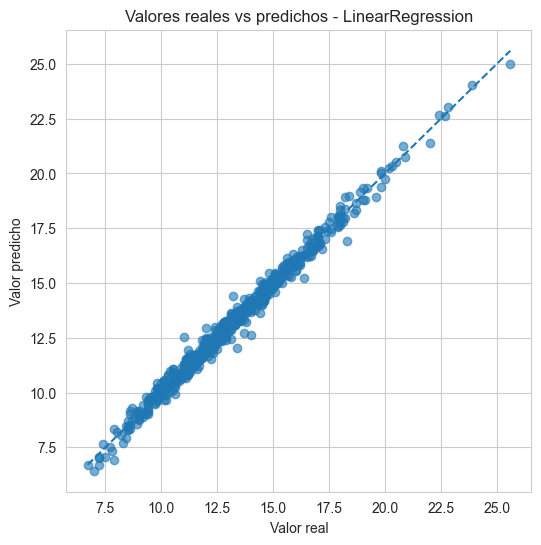

In [24]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("Valores reales vs predichos - LinearRegression")
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Este grafico muestra que el modelo de regresion lineal hizo un trabajo muy bueno. La mayoria de los puntos quedan muy cerca de la linea diagonal, y eso significa que los valores que el modelo predijo son muy parecidos a los valores reales. Dicho de una forma simple, el modelo no se alejo mucho de la realidad y logro seguir bastante bien el comportamiento de los datos. Esto da confianza, porque indica que sus predicciones fueron precisas y consistentes.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Modelo Lasso
</h2>

<div style="
  font-size: 20px;
  line-height: 1.7;
  color: #1f2937;
  background-color: #f8fafc;
  border-left: 6px solid #38bdf8;
  padding: 16px 18px;
  border-radius: 10px;
">
Ahora se entrena un modelo <b>Lasso</b>. A diferencia de la regresion lineal clasica, Lasso penaliza los coeficientes y tiende a simplificar el modelo. Esto puede ser util cuando hay muchas variables y se busca un equilibrio entre rendimiento e interpretacion.
</div>

In [ ]:
lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=1.0, max_iter=10000))])

lasso_model.fit(X_train, y_train)

print("Modelo Lasso entrenado correctamente.")

Modelo Lasso entrenado correctamente.


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Evaluacion del modelo Lasso
</h2>

In [ ]:
y_train_pred_lasso = lasso_model.predict(X_train)
y_test_pred_lasso = lasso_model.predict(X_test)

lasso_metrics = pd.DataFrame({
    "dataset": ["train", "test"],
    "r2": [
        r2_score(y_train, y_train_pred_lasso),
        r2_score(y_test, y_test_pred_lasso)],
    "mae": [
        mean_absolute_error(y_train, y_train_pred_lasso),
        mean_absolute_error(y_test, y_test_pred_lasso)],
    "rmse": [
        np.sqrt(mean_squared_error(y_train, y_train_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))]})

lasso_metrics

,dataset,r2,mae,rmse
0,train,0.761686,1.051481,1.315246
1,test,0.765283,1.103350,1.373995


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Comparacion entre el modelo baseline y Lasso
</h2>

In [27]:
baseline_metrics["model"] = "LinearRegression"
lasso_metrics["model"] = "Lasso"

comparison_metrics = pd.concat([baseline_metrics, lasso_metrics], ignore_index=True)
comparison_metrics = comparison_metrics[["model", "dataset", "r2", "mae", "rmse"]]

comparison_metrics

,model,dataset,r2,mae,rmse
0,LinearRegression,train,0.989327,0.210708,0.278336
1,LinearRegression,test,0.988947,0.220756,0.298157
2,Lasso,train,0.761686,1.051481,1.315246
3,Lasso,test,0.765283,1.103350,1.373995


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La tabla muestra que la regresion lineal fue claramente el modelo que mejor funciono. Obtuvo un rendimiento muy alto tanto en entrenamiento como en prueba, y ademas mantuvo errores bajos en ambos casos. Esto indica que el modelo aprendio bien y tambien respondio bien con datos nuevos. En cambio, Lasso tuvo un rendimiento bastante menor y errores mucho mas altos, lo que sugiere que simplifico demasiado la informacion y por eso perdio capacidad de prediccion.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
📈 Evolucion de R² al variar el hiperparametro alpha en Lasso
</h2>

<div style="
  font-size: 20px;
  line-height: 1.7;
  color: #1f2937;
  background-color: #f8fafc;
  border-left: 6px solid #38bdf8;
  padding: 16px 18px;
  border-radius: 10px;
">
Para entender mejor el comportamiento de <b>Lasso</b>, se prueba el modelo con varios valores de <b>alpha</b>. En palabras simples, cuanto mayor es alpha, mayor es la penalizacion aplicada a los coeficientes. El objetivo es ver hasta que punto esa simplificacion sigue siendo util y a partir de cuando empieza a deteriorar el rendimiento.
</div>

In [ ]:
alphas = np.linspace(0.01, 20, 40)

r2_train_scores = []
r2_test_scores = []

for alpha in alphas:
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=alpha, max_iter=10000))])

    model.fit(X_train, y_train)

    y_train_pred_alpha = model.predict(X_train)
    y_test_pred_alpha = model.predict(X_test)

    r2_train_scores.append(r2_score(y_train, y_train_pred_alpha))
    r2_test_scores.append(r2_score(y_test, y_test_pred_alpha))

lasso_alpha_results = pd.DataFrame({
    "alpha": alphas,
    "r2_train": r2_train_scores,
    "r2_test": r2_test_scores})

lasso_alpha_results.head()

,alpha,r2_train,r2_test
0,0.010000,0.971579,0.971682
1,0.522564,0.886639,0.889398
2,1.035128,0.750117,0.753705
3,1.547692,0.540046,0.543746
4,2.060256,0.267635,0.269789


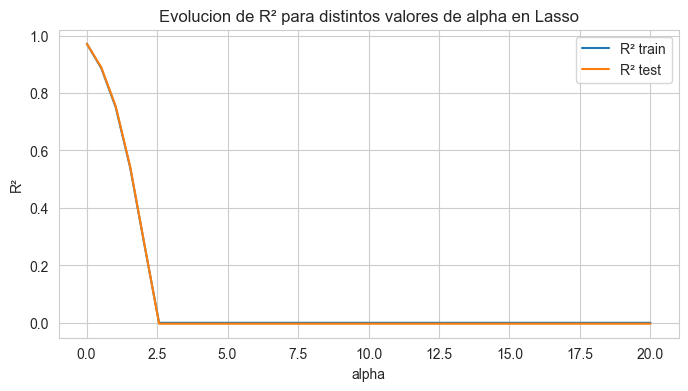

In [29]:
plt.figure(figsize=(8, 4))
plt.plot(lasso_alpha_results["alpha"], lasso_alpha_results["r2_train"], label="R² train")
plt.plot(lasso_alpha_results["alpha"], lasso_alpha_results["r2_test"], label="R² test")
plt.title("Evolucion de R² para distintos valores de alpha en Lasso")
plt.xlabel("alpha")
plt.ylabel("R²")
plt.legend()
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">La lectura de esta curva es muy intuitiva, si <span style="color: #ef4444; font-weight: 700;">alpha</span> crece demasiado, el modelo se vuelve mas rigido y empieza a perder capacidad para ajustarse a los datos. Si alpha es muy pequeño, Lasso se comporta de forma mas parecida a la regresion lineal clasica. Lo importante aqui es encontrar un punto intermedio en el que el modelo siga siendo fuerte sin simplificar en exceso.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
🔧 Optimizacion del modelo Lasso
</h2>

<div style="
  font-size: 20px;
  line-height: 1.7;
  color: #1f2937;
  background-color: #f8fafc;
  border-left: 6px solid #38bdf8;
  padding: 16px 18px;
  border-radius: 10px;
">
Despues de observar la curva de rendimiento, se utiliza <b>GridSearchCV</b> para buscar de forma sistematica un valor de <b>alpha</b> mas adecuado. Esta etapa ayuda a elegir la configuracion con mejor equilibrio segun validacion cruzada.
</div>

In [30]:
lasso_grid_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=10000))
])

param_grid = {
    "model__alpha": [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
}

grid_search = GridSearchCV(
    estimator=lasso_grid_model,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print("Mejor alpha encontrado:", grid_search.best_params_["model__alpha"])
print("Mejor score promedio en validacion cruzada:", grid_search.best_score_)

Mejor alpha encontrado: 0.001
Mejor score promedio en validacion cruzada: 0.9848225782388157


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este paso se probo el modelo Lasso con varios valores de alpha para encontrar la configuracion que mejor funcionara. En lugar de elegir ese valor a mano, se hizo una busqueda automatica y ordenada. De esta forma se pudo seleccionar la version del modelo que daba el mejor resultado promedio, lo que ayuda a obtener un modelo mas solido y mejor ajustado.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Evaluacion del mejor modelo Lasso
</h2>

In [31]:
best_lasso = grid_search.best_estimator_

y_train_pred_best = best_lasso.predict(X_train)
y_test_pred_best = best_lasso.predict(X_test)

best_lasso_metrics = pd.DataFrame({
    "dataset": ["train", "test"],
    "r2": [
        r2_score(y_train, y_train_pred_best),
        r2_score(y_test, y_test_pred_best)
    ],
    "mae": [
        mean_absolute_error(y_train, y_train_pred_best),
        mean_absolute_error(y_test, y_test_pred_best)
    ],
    "rmse": [
        np.sqrt(mean_squared_error(y_train, y_train_pred_best)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_best))
    ]
})

best_lasso_metrics

,dataset,r2,mae,rmse
0,train,0.987117,0.234187,0.305801
1,test,0.987086,0.240790,0.322286


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
📈 Coeficientes mas influyentes del mejor modelo Lasso
</h2>

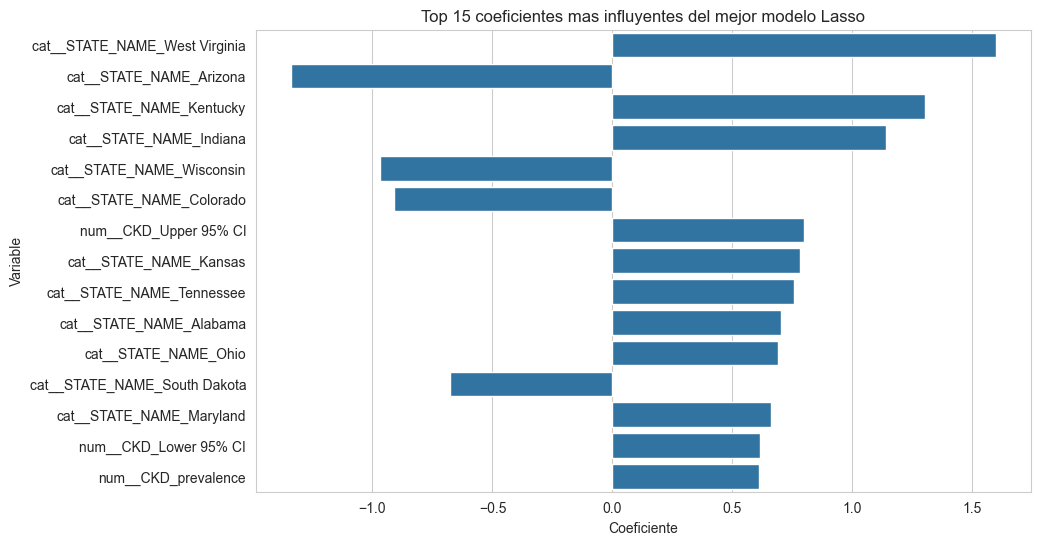

In [32]:
feature_names = best_lasso.named_steps["preprocessor"].get_feature_names_out()
coefficients = best_lasso.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefficients
})

coef_df["abs_coef"] = coef_df["coef"].abs()
top_coef = coef_df.sort_values("abs_coef", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_coef, x="coef", y="feature")
plt.title("Top 15 coeficientes mas influyentes del mejor modelo Lasso")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">Este gráfico muestra las variables que más influyeron en el mejor modelo Lasso. Se observa que varios estados tuvieron un peso importante en la predicción, lo que indica que la ubicación geográfica sí aporta información útil. También aparecen variables relacionadas con enfermedad renal (enfermedad renal cronica CKD), lo que sugiere una relación clara entre estos indicadores de salud y la prevalencia de diabetes. En conjunto, el gráfico ayuda a entender que el modelo se apoyó principalmente en factores geográficos y de salud para hacer sus predicciones.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
">
Tabla comparativa de modelos
</h2>

In [33]:
best_lasso_metrics["model"] = "Lasso optimizado"

final_comparison = pd.concat(
    [baseline_metrics, lasso_metrics, best_lasso_metrics],
    ignore_index=True
)

final_comparison = final_comparison[["model", "dataset", "r2", "mae", "rmse"]]
final_comparison

,model,dataset,r2,mae,rmse
0,LinearRegression,train,0.989327,0.210708,0.278336
1,LinearRegression,test,0.988947,0.220756,0.298157
2,Lasso,train,0.761686,1.051481,1.315246
3,Lasso,test,0.765283,1.103350,1.373995
4,Lasso optimizado,train,0.987117,0.234187,0.305801
5,Lasso optimizado,test,0.987086,0.240790,0.322286


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">De los tres modelos, el que mejor trabajó fue la regresión lineal. Dio resultados muy buenos y se comportó casi igual con datos de entrenamiento y con datos nuevos, lo cual da confianza. El Lasso al principio fue peor, pero después de ajustarlo mejoró bastante. Aun así, el modelo más fuerte y más claro para este proyecto fue la regresión lineal.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
">
Conclusion final
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">La prevalencia de diabetes puede explicarse en buena medida a partir de variables socio demograficas y de recursos de salud del condado, el entorno social, economico y sanitario del territorio si guarda relacion con el nivel de diabetes observado.</p>
</div>